# Foundation Model Embedding + Fusion Classifier Comparison

This notebook merges two pieces of work:

1. **Embedding pipeline** (adapted from Arda's general embedding-framework script) — runs the
   in-house fused / parental / resistant cells through the pretrained `sc_embedd` model to get a
   low-dimensional latent representation.
2. **Classifier pipeline** (adapted from my script `Fusion_signature_Oct2025.ipynb`) — trains RF and RF+LDA
   classifiers to predict sample identity (fused / parental / resistant).

Workflow: preprocess in-house data → embed with `sc_embedd` → train/test RF and RF+LDA classifiers
on the **embedding** → compare against the classifiers trained on raw HVG expression (original
notebook results reproduced here for a side-by-side comparison).

## 0. Assumptions status

- **Gene panel — resolved.** `MODEL_FEAT_PATH` should point at the real feature file found on the
  cluster; Section 2 reindexes the in-house data to match it exactly. When last run, the feature
  count matched the model's expected input width (1548) exactly — treat this as trustworthy since
  it's sourced from the model's own metadata, not a guess.
- **Batch covariate — open, stopgap in place.** `sc_embedd` expects a 19-wide batch one-hot
  (confirmed from a shape-mismatch error), not `sample` (fused/parental/resistant, 3-wide). Those
  19 categories are training batches our in-house cells were never part of, so there's no correct
  per-cell mapping onto them. Section 3 assigns every cell a single fixed reference category as a
  stopgap; Section 4 includes a diagnostic that checks whether the embedding output is even
  sensitive to that choice before you trust downstream results.
- **Preprocessing state**: we feed the model normalized + log1p-transformed counts on the full
  gene panel (not the HVG-subset/scaled/regressed matrix used for the RF classifiers). Not
  independently verified against how the model was trained, but consistent with the original
  script's apparent preprocessing convention.

## Imports

In [ ]:
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
import joblib

import tensorflow as tf

# classifier pieces (same as Fusion_signature_Oct2025.ipynb)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, cross_validate, StratifiedKFold, train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report,
    roc_curve, roc_auc_score,
)

from sklearn.manifold import TSNE
import seaborn as sns

import gseapy as gp
from gseapy import barplot

## Paths

`wd` is the cluster location for the pretrained model (from Arda's script, now pointed at your
storage). Adjust `MODEL_FEAT_PATH` if the model ships with an explicit gene-panel file — otherwise
leave it `None` and gene alignment will be skipped (see assumptions above).

In [ ]:
wd = '/mnt/vstor/SOM_CCCC_JGS25/durmaza/'

MODEL_DIR = f'{wd}/sc_embedd_model/2/'  # retrained with a probabilistic (dropout-aware) objective -- see Section 4
MODEL_FEAT_PATH = f'{wd}/lung_ext_feat.tsv.gz'  # e.g. f'{wd}/sc_embedd_feat.tsv.gz' — set this if the model ships a fixed gene panel

results_file = 'combined_analyzed_Oct2025.h5ad'  # written by Fusion_signature_Oct2025.ipynb

## 1. Load In-House Data

Reuses the fused / parental / resistant loading + QC from `Fusion_signature_Oct2025.ipynb`. Raw
filtered counts are shared (QC thresholds are identical either way), but normalization then splits
into two **independent** branches: `adata_embed_input` (whatever preprocessing `sc_embedd` needs)
and `adata_combined_filtered` (frozen to the exact original notebook's preprocessing, for a
faithful Section 8 baseline). See the next cell for why they're kept separate rather than shared.

In [88]:
adata_fus = sc.read_10x_mtx('../fused/', var_names='gene_symbols', cache=True)
adata_fus.obs['sample'] = 'fused'
adata_fus.obs.index = [f'F_{bc}' for bc in adata_fus.obs.index]

adata_par = sc.read_10x_mtx('../parental/', var_names='gene_symbols', cache=True)
adata_par.obs['sample'] = 'parental'
adata_par.obs.index = [f'P_{bc}' for bc in adata_par.obs.index]

adata_res = sc.read_10x_mtx('../resistant/', var_names='gene_symbols', cache=True)
adata_res.obs['sample'] = 'resistant'
adata_res.obs.index = [f'R_{bc}' for bc in adata_res.obs.index]

for a in (adata_fus, adata_par, adata_res):
    a.var_names_make_unique()

adata_combined = ad.concat([adata_fus, adata_par, adata_res])

In [89]:
# QC + filtering (mirrors Fusion_signature_Oct2025.ipynb)
adata_combined.var['mt'] = adata_combined.var_names.str.startswith('MT-')
sc.pp.calculate_qc_metrics(adata_combined, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

sc.pp.filter_cells(adata_combined, min_genes=200)
sc.pp.filter_genes(adata_combined, min_cells=3)

adata_combined_filtered = adata_combined[adata_combined.obs.total_counts < 75000, :]
adata_combined_filtered = adata_combined_filtered[adata_combined_filtered.obs.n_genes > 1000, :]
adata_combined_filtered = adata_combined_filtered[adata_combined_filtered.obs.pct_counts_mt < 40, :]
adata_combined_filtered = adata_combined_filtered.copy()

# Raw filtered counts only -- normalization is applied per-branch in the next cell so the
# embedding preprocessing and the classifier-reproduction preprocessing can never again silently
# share (and corrupt) each other. See that cell for why this matters.

In [90]:
# Embedding-model branch: full gene panel, whatever normalization sc_embedd expects (currently
# exclude_highly_expressed=True, target_sum=1e8, asinh transform -- carried over from cluster-side
# tuning). Kept independent of the classifier-reproduction branch below so changes here can never
# again silently corrupt the "reproduce the original classifiers" baseline in Section 8 -- that's
# what caused HVG RF/RF+LDA accuracy to collapse to ~0.47 (from 0.917/0.951 in the original
# notebook) when both branches shared one normalize_total call.
def asinh(x):
    return np.log(x + np.sqrt(x**2.0 + 1.0))

adata_embed_input = adata_combined_filtered.copy()
sc.pp.normalize_total(adata_embed_input, exclude_highly_expressed=True, target_sum=1e8)
adata_embed_input.X = asinh(adata_embed_input.X.toarray())

# Original-classifier-reproduction branch: rebuilt independently from the raw filtered counts
# using the EXACT preprocessing from Fusion_signature_Oct2025.ipynb (target_sum=1e6, plain
# log1p, no exclude_highly_expressed), so Section 8 stays a faithful, fixed baseline regardless
# of what preprocessing the embedding branch above evolves to.
adata_combined_filtered = adata_combined_filtered.copy()
sc.pp.normalize_total(adata_combined_filtered, target_sum=1e6)
sc.pp.log1p(adata_combined_filtered)
sc.pp.highly_variable_genes(adata_combined_filtered, min_mean=0.0125, max_mean=3, min_disp=0.5)
adata_combined_filtered = adata_combined_filtered[:, adata_combined_filtered.var.highly_variable].copy()
sc.pp.regress_out(adata_combined_filtered, ['total_counts', 'pct_counts_mt'])
sc.pp.scale(adata_combined_filtered, max_value=10)
adata_combined_filtered.write_h5ad(results_file)

## 2. Align Genes to the Model's Expected Panel

Skipped (with a warning) if `MODEL_FEAT_PATH` is `None`.

In [91]:
if MODEL_FEAT_PATH is not None:
    model_feat = pd.read_csv(MODEL_FEAT_PATH, sep='\t')
    model_genes = model_feat.iloc[:, 0].astype(str).tolist()

    n_matched = adata_embed_input.var_names.isin(model_genes).sum()
    print(f'{n_matched}/{len(model_genes)} model genes found in in-house panel')

    adata_embed_input = adata_embed_input[:, [g for g in model_genes if g in adata_embed_input.var_names]]
    # reindex to the model's exact gene order, filling any still-missing genes with 0
    missing = [g for g in model_genes if g not in adata_embed_input.var_names]
    if missing:
        print(f'Filling {len(missing)} genes absent from in-house data with 0 expression')
        pad = ad.AnnData(
            X=np.zeros((adata_embed_input.n_obs, len(missing)), dtype=np.float32),
            obs=adata_embed_input.obs,
            var=pd.DataFrame(index=missing),
        )
        adata_embed_input = ad.concat([adata_embed_input, pad], axis=1)
    adata_embed_input = adata_embed_input[:, model_genes].copy()
else:
    print('MODEL_FEAT_PATH not set — using in-house gene panel as-is. '
          'Verify this matches what sc_embedd expects before trusting the embedding.')

1548/1548 model genes found in in-house panel


## 3. Batch Covariate

**Diagnosed from a shape-mismatch error**: `sc_embedd` expects a **19-wide** one-hot batch
covariate (`input_2` shape `(None, 19)`), not the 3-wide `sample` (fused/parental/resistant)
encoding used before. Those 19 categories are almost certainly the *training* batches (e.g. from
the lung_ext data), which our in-house cells were never assigned to — there's no principled
per-cell mapping from "fused"/"parental"/"resistant" into that set.

Two things, in order:

1. **Look for the original training `obs` file**, in the same place you found the feat file
   (likely named like `lung_ext_obs.tsv.gz`, matching the original script). If its `batch` column
   has exactly 19 unique values, that's the real category list/order — point `BATCH_OBS_PATH`
   below at it. This gives real names for documentation and a width sanity-check, but it still
   doesn't tell us which of those 19 batches our in-house cells belong to — they don't belong to
   any of them.
2. **Stopgap**: assign every in-house cell to a single fixed reference category
   (`REFERENCE_BATCH_INDEX`, default `0`) so the call is at least shape-valid. Whether this is a
   *reasonable* assumption (vs. actively wrong) depends on whether the embedding branch is even
   sensitive to the batch input — Section 4 checks that before running the full dataset through
   the model.

In [92]:
BATCH_WIDTH = 19  # from the ValueError in Section 4: sc_embedd's input_2 expects shape (None, 19)

# obs['sample'] (fused/parental/resistant) cannot be the batch covariate -- only 3 categories,
# not the 19 the model expects. Those 19 are training batches our in-house cells were never part
# of, so there's no correct per-cell mapping onto them.
BATCH_OBS_PATH = None  # e.g. f'{wd}/lung_ext_obs.tsv.gz' -- set if you find the original training obs file

if BATCH_OBS_PATH is not None:
    train_obs = pd.read_csv(BATCH_OBS_PATH, sep='\t')
    batch_categories = sorted(train_obs['batch'].drop_duplicates().tolist())
    assert len(batch_categories) == BATCH_WIDTH, (
        f'{len(batch_categories)} categories found in {BATCH_OBS_PATH}, model expects '
        f'{BATCH_WIDTH} -- this is probably not the right source file.'
    )
    print(f'Loaded {len(batch_categories)} training batch categories from {BATCH_OBS_PATH}')
else:
    batch_categories = [f'unknown_batch_{i}' for i in range(BATCH_WIDTH)]
    print(f'BATCH_OBS_PATH not set -- using placeholder category names. Model still expects a '
          f'{BATCH_WIDTH}-wide one-hot input regardless.')

# Stopgap: every in-house cell gets assigned the same single reference category, since no
# per-cell mapping into the 19 training batches exists for our data. See Section 4 for a check
# of whether the embedding output is even sensitive to this choice.
REFERENCE_BATCH_INDEX = 0
print(f'Using "{batch_categories[REFERENCE_BATCH_INDEX]}" (index {REFERENCE_BATCH_INDEX}) as the '
      'reference batch for all in-house cells.')

x_batch = np.zeros((adata_embed_input.n_obs, BATCH_WIDTH), dtype=np.float32)
x_batch[:, REFERENCE_BATCH_INDEX] = 1.0
print(f'x_batch shape: {x_batch.shape}')

BATCH_OBS_PATH not set -- using placeholder category names. Model still expects a 19-wide one-hot input regardless.
Using "unknown_batch_0" (index 0) as the reference batch for all in-house cells.
x_batch shape: (24205, 19)


## 4. Run the Embedding Model

**Model updated to `sc_embedd_model/2/`** -- retrained with a probabilistic objective (better suited
to single-cell dropout noise than the original model). Confirmed output structure (per Arda):
`sc_embedd(...)` returns `(embeddings, [pi, mu, logvar], reg)` -- a ZINB/VAE-style parameterization
where `pi` is the dropout/zero-inflation probability, `mu` is the reconstruction mean, `logvar` is
the log-variance, and `reg` is a regularization term.

- **Embeddings (`out[0]`) are unaffected** -- same shape/meaning as the old model, so `emb_res` and
  everything downstream of it (classifiers, GSEA, the minimum-feature sweep) needs no changes.
- **Reconstruction now needs `out[1][1]` (`mu`), not `out[1]`** -- `out[1]` is a 3-element list, not
  a single tensor, so the old `out[1].numpy()` pattern would fail outright. Updated below wherever
  `pred_res`/reconstruction values are read. `pi` (`out[1][0]`) and `logvar` (`out[1][2]`) are
  available if a future analysis wants dropout probability or uncertainty specifically, but aren't
  used here.

Loads the pretrained `sc_embedd` model and runs it over the in-house data in batches, exactly as
in the original script. The model directory is a legacy TF SavedModel export (note the version
subdirectory), which Keras 3's `tf.keras.models.load_model` can no longer read — we load it with
`tf.saved_model.load` instead and call it directly, which preserves the original
`sc_embedd([expr, batch], training=False)` call signature. If the direct call raises instead (some
exports only expose a `serving_default` signature with named, not positional, inputs), the cell
prints the signature's input/output names so you can adapt the call.

In [ ]:
expr = adata_embed_input.X
if hasattr(expr, 'toarray'):
    expr = expr.toarray()
expr = expr.astype(np.float32)

# Keras 3 dropped support for loading a bare TF SavedModel via load_model(); load it as a
# raw SavedModel and call it directly instead (works if it was exported as a Keras SavedModel
# and still exposes its original __call__).
sc_embedd = tf.saved_model.load(MODEL_DIR)

try:
    sig = sc_embedd.signatures['serving_default']
    print('Model signature inputs:', sig.structured_input_signature)
    print('Model signature outputs:', sig.structured_outputs)
except Exception as exc:
    print(f'No serving_default signature available to introspect ({exc!r}).')
print(f'In-house feature count feeding the model: {expr.shape[1]} (compare to input_1 width above)')
print(f'In-house batch covariate width: {x_batch.shape[1]} (compare to input_2 width above)')

try:
    _test = sc_embedd([expr[:2], x_batch[:2]], training=False)
    call_fn = lambda e, b: sc_embedd([e, b], training=False)
    print('Loaded sc_embedd via tf.saved_model.load; calling it directly.')
except Exception as exc:
    print(f'Direct call failed ({exc!r}); inspect the signature above and adjust call_fn / '
          'the input shapes above (feature count, batch width) before retrying.')
    raise

# Confirmed structure (per Arda): out = (embeddings, [pi, mu, logvar], reg). out[1] is a 3-element
# list, not a single tensor -- print it that way so this stays visible rather than assumed.
_test_list = list(_test.values()) if isinstance(_test, dict) else list(_test)
print(f'Direct-call output count: {len(_test_list)}')
for oi, o in enumerate(_test_list):
    if isinstance(o, (list, tuple)):
        print(f'  out[{oi}] is a list of {len(o)} tensors:')
        for si, sub in enumerate(o):
            print(f'    out[{oi}][{si}] shape: {tuple(sub.shape)}')
    else:
        print(f'  out[{oi}] shape: {tuple(o.shape)}')
print('out[0] = embeddings, out[1] = [pi, mu, logvar] (pi = dropout/zero-inflation probability, '
      'mu = mean, logvar = log-variance), out[2] = a regularization term. Reconstruction/mean '
      'values use out[1][1] (mu), not out[1] directly.')

# Sensitivity check: does the embedding output actually depend on which reference batch index
# we picked in Section 3, or only the reconstruction? If emb is unaffected, the
# REFERENCE_BATCH_INDEX stopgap is low-risk for classifier training even without real per-cell
# batch labels. If it IS affected, that stopgap is actively shaping the embedding and needs a
# principled batch assignment before trusting downstream results.
probe_expr = expr[:min(16, expr.shape[0])]
probe_batch_a = np.zeros((probe_expr.shape[0], BATCH_WIDTH), dtype=np.float32)
probe_batch_a[:, 0] = 1.0
probe_batch_b = np.zeros((probe_expr.shape[0], BATCH_WIDTH), dtype=np.float32)
probe_batch_b[:, min(1, BATCH_WIDTH - 1)] = 1.0

out_a = call_fn(probe_expr, probe_batch_a)
out_b = call_fn(probe_expr, probe_batch_b)
if isinstance(out_a, dict):
    out_a, out_b = list(out_a.values()), list(out_b.values())
mu_a, mu_b = out_a[1][1], out_b[1][1]  # out[1] = [pi, mu, logvar]; mu is the reconstruction mean
emb_diff = np.abs(out_a[0].numpy() - out_b[0].numpy()).max()
pred_diff = np.abs(mu_a.numpy() - mu_b.numpy()).max()
print(f'Max |embedding difference| between two reference-batch choices: {emb_diff:.6f}')
print(f'Max |reconstruction difference| between two reference-batch choices: {pred_diff:.6f}')
print('If the embedding difference above is ~0, batch choice mainly affects reconstruction and '
      'the REFERENCE_BATCH_INDEX stopgap is low-risk for the embedding used in classifiers. If '
      "it's large, the stopgap materially shapes the embedding and needs a real per-cell batch "
      'assignment before trusting downstream results.')

ds = tf.data.Dataset.from_tensor_slices((expr, x_batch))
ds = ds.batch(32)

emb_res = []
pred_res = []
for step, local_batch in enumerate(ds):
    print(f'\rProcessing step {step}', end='')
    out = call_fn(local_batch[0], local_batch[1])
    if isinstance(out, dict):
        out = list(out.values())
    emb_res.append(out[0].numpy())
    pred_res.append(out[1][1].numpy())  # out[1] = [pi, mu, logvar]; mu is the reconstruction mean

emb_res = np.vstack(emb_res)
pred_res = np.vstack(pred_res)
print(f'\nEmbedding shape: {emb_res.shape}, prediction shape: {pred_res.shape}')

## 5. Reconstruction Diagnostic

Sample 100 cells (row index into `pred_res`/`expr`) and compare predicted vs. observed expression.
The original script sampled from `pred_res.shape[1]` (the gene axis) — corrected here to sample
`pred_res.shape[0]` (the cell axis), which is what "100 random cells" should mean.

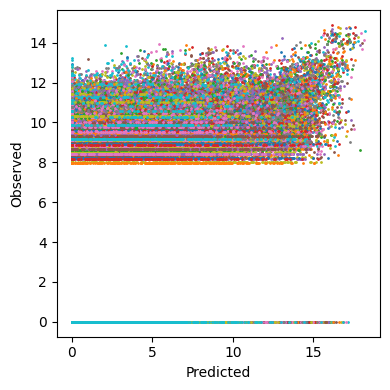

In [94]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
for idx in np.random.choice(np.arange(pred_res.shape[0]), size=min(100, pred_res.shape[0]), replace=False):
    ax.scatter(pred_res[idx, ], expr[idx, ], s=1)
ax.set_xlabel('Predicted')
ax.set_ylabel('Observed')
plt.tight_layout()
plt.show()

## 6. t-SNE of the Embedding

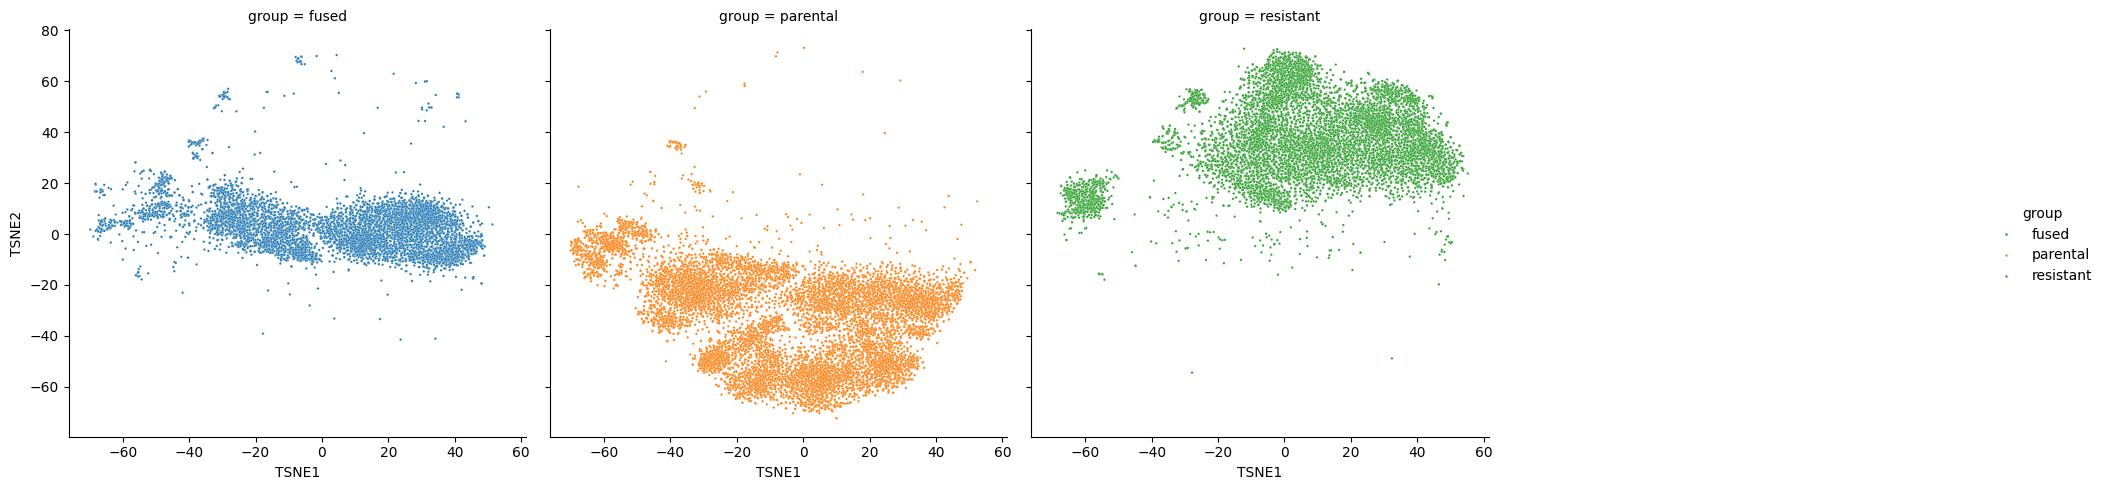

In [95]:
tsne_res = TSNE(n_components=2, n_jobs=-1).fit_transform(emb_res)
df_tsne = pd.DataFrame({
    'group': adata_embed_input.obs['sample'].values,
    'TSNE1': tsne_res[:, 0],
    'TSNE2': tsne_res[:, 1],
})

sns.relplot(df_tsne, x='TSNE1', y='TSNE2', hue='group', kind='scatter', s=3, col='group', col_wrap=4)
plt.savefig('tsne_res_sc_embedding.png')
plt.show()

## 6b. Map In-House Cells onto the Reference (`lung_ext`) Embedding Space

The t-SNE above only shows your in-house cells relative to each other. To see whether/where they
overlap with the broader population `sc_embedd` was trained on, embed the reference cohort too and
plot both in one shared t-SNE (embedding new + reference points together, rather than projecting
onto a fixed space, since plain t-SNE has no `.transform()` for out-of-sample points).

Needs the original `lung_ext_obs.tsv.gz` / `lung_ext_mat.npy` files (likely sitting next to the
`lung_ext_feat.tsv.gz` you already found for `MODEL_FEAT_PATH`). Set the paths below once located.

**Caveat**: the reference cohort gets embedded using its *own real* per-cell batch labels (from
`ref_obs['batch']`), while your in-house cells still use the `REFERENCE_BATCH_INDEX` stopgap from
Section 3 — check Section 4's sensitivity result before reading too much into exact positions of
in-house cells relative to reference clusters; the source-level separation is more trustworthy than
fine-grained placement if the embedding turned out to be batch-sensitive.

If `ref_obs['batch']` turns out to have exactly 19 unique values, that's also your answer for the
real training batch categories — worth feeding back into `BATCH_OBS_PATH` in Section 3.

In [96]:
REF_OBS_PATH = f'{wd}/lung_ext_obs.tsv.gz'   # e.g. f'{wd}/lung_ext_obs.tsv.gz'
REF_MAT_PATH = f'{wd}/lung_ext_mat.npy'   # e.g. f'{wd}/lung_ext_mat.npy'

if REF_OBS_PATH is not None and REF_MAT_PATH is not None:
    ref_obs = pd.read_csv(REF_OBS_PATH, sep='\t')
    ref_expr = np.load(REF_MAT_PATH).astype(np.float32)
    assert ref_expr.shape[0] == ref_obs.shape[0], (
        f'{ref_expr.shape[0]} cells in {REF_MAT_PATH} vs {ref_obs.shape[0]} rows in '
        f'{REF_OBS_PATH} -- these files are not a matched pair.'
    )
    assert ref_expr.shape[1] == expr.shape[1], (
        f'Reference feature width {ref_expr.shape[1]} != in-house feature width {expr.shape[1]} '
        '-- reference matrix is not on the same gene panel as MODEL_FEAT_PATH.'
    )

    ref_uniq_s = sorted(list(ref_obs['batch'].drop_duplicates()))
    ref_uniq_m = dict(zip(ref_uniq_s, np.arange(len(ref_uniq_s))))
    ref_x_batch = np.vstack([
        np.eye(len(ref_uniq_s), dtype=np.float32)[ref_uniq_m[s], ] for s in ref_obs['batch']
    ])
    print(f'Reference batch categories ({len(ref_uniq_s)}): {ref_uniq_s}')
    assert ref_x_batch.shape[1] == BATCH_WIDTH, (
        f'Reference batch width {ref_x_batch.shape[1]} != model-expected {BATCH_WIDTH} -- '
        'this obs file is probably not the actual training cohort.'
    )

    ref_ds = tf.data.Dataset.from_tensor_slices((ref_expr, ref_x_batch)).batch(32)
    ref_emb_res = []
    for step, local_batch in enumerate(ref_ds):
        print(f'\rEmbedding reference step {step}', end='')
        out = call_fn(local_batch[0], local_batch[1])
        if isinstance(out, dict):
            out = list(out.values())
        ref_emb_res.append(out[0].numpy())
    ref_emb_res = np.vstack(ref_emb_res)
    print(f'\nReference embedding shape: {ref_emb_res.shape}')
else:
    ref_emb_res = None
    print('REF_OBS_PATH / REF_MAT_PATH not set -- skipping reference embedding. Look for '
          'lung_ext_obs.tsv.gz and lung_ext_mat.npy alongside the feat file used for '
          'MODEL_FEAT_PATH.')

Reference batch categories (19): ['KNUH01', 'KNUH02', 'KNUH03', 'KNUH04', 'KNUH05', 'KNUH06', 'KNUH07', 'KNUH08', 'KNUH09', 'KNUH11', 'KNUH12', 'KNUH13', 'KNUH14', 'KNUH16', 'KNUH18', 'KNUH19', 'KNUH20', 'KNUH22', 'in-house']
Embedding reference step 2023
Reference embedding shape: (64763, 128)


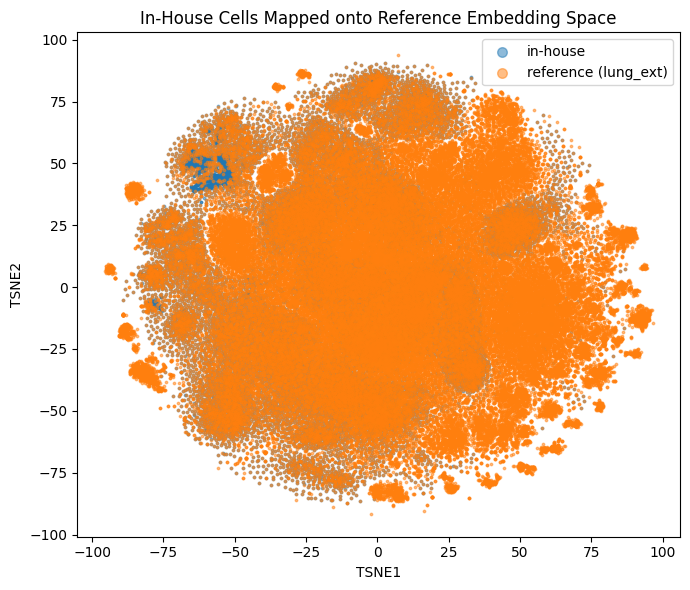

In [97]:
if ref_emb_res is not None:
    ref_group = (
        list(ref_obs['cell_type']) if 'cell_type' in ref_obs.columns
        else ['reference'] * ref_emb_res.shape[0]
    )
    joint_emb = np.vstack([ref_emb_res, emb_res])
    joint_source = (['reference (lung_ext)'] * ref_emb_res.shape[0]
                     + ['in-house'] * emb_res.shape[0])
    joint_group = ref_group + list(adata_embed_input.obs['sample'].values)

    joint_tsne = TSNE(n_components=2, n_jobs=-1, random_state=42).fit_transform(joint_emb)
    df_joint = pd.DataFrame({
        'source': joint_source,
        'group': joint_group,
        'TSNE1': joint_tsne[:, 0],
        'TSNE2': joint_tsne[:, 1],
    })

    fig, ax = plt.subplots(1, 1, figsize=(7, 6))
    for src, sub in df_joint.groupby('source'):
        ax.scatter(sub['TSNE1'], sub['TSNE2'], s=3, alpha=0.5, label=src)
    ax.set_xlabel('TSNE1')
    ax.set_ylabel('TSNE2')
    ax.set_title('In-House Cells Mapped onto Reference Embedding Space')
    ax.legend(markerscale=4)
    plt.tight_layout()
    plt.savefig('tsne_inhouse_vs_reference.png')
    plt.show()
else:
    print('Skipping joint plot -- set REF_OBS_PATH / REF_MAT_PATH in the previous cell first.')

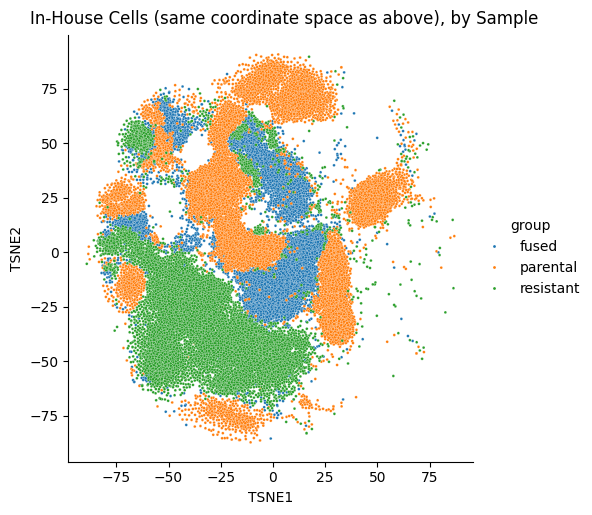

No 'cell_type' column in ref_obs -- skipping the reference-cell-type overlay plot.


In [98]:
if ref_emb_res is not None:
    sns.relplot(
        df_joint[df_joint['source'] == 'in-house'],
        x='TSNE1', y='TSNE2', hue='group', kind='scatter', s=4,
    )
    plt.suptitle('In-House Cells (same coordinate space as above), by Sample', y=1.02)
    plt.show()

    # Reference cell types as biological context (if the obs file carries them), with in-house
    # cells overlaid on top -- shows which reference cell-type neighborhoods your data lands near.
    if 'cell_type' in ref_obs.columns:
        fig, ax = plt.subplots(1, 1, figsize=(8, 7))
        ref_mask = df_joint['source'] == 'reference (lung_ext)'
        for ct, sub in df_joint[ref_mask].groupby('group'):
            ax.scatter(sub['TSNE1'], sub['TSNE2'], s=2, alpha=0.35, label=ct)
        inhouse_mask = df_joint['source'] == 'in-house'
        ax.scatter(df_joint.loc[inhouse_mask, 'TSNE1'], df_joint.loc[inhouse_mask, 'TSNE2'],
                   s=6, color='black', alpha=0.8, label='in-house (all)')
        ax.set_title('In-House Cells Overlaid on Reference Cell Types')
        ax.legend(fontsize='xx-small', markerscale=3, ncol=2, bbox_to_anchor=(1.02, 1), loc='upper left')
        plt.tight_layout()
        plt.savefig('tsne_inhouse_over_reference_celltypes.png')
        plt.show()
    else:
        print("No 'cell_type' column in ref_obs -- skipping the reference-cell-type overlay plot.")

## 7. Train RF / RF+LDA Classifiers on the Embedding

Same classifier setup as `Fusion_signature_Oct2025.ipynb` (`SelectKBest` → optional LDA → Random
Forest, 10-fold stratified CV), but with `X = emb_res` instead of raw HVG expression. `k_best` is
capped at the embedding's actual dimensionality since `emb_res` is already low-dimensional.

In [99]:
X_emb = emb_res
y_emb = adata_embed_input.obs['sample'].values

X_emb_train, X_emb_test, y_emb_train, y_emb_test = train_test_split(
    X_emb, y_emb, test_size=0.2, random_state=42, stratify=y_emb
)

k_best_emb = min(2000, X_emb.shape[1])
selector_emb = SelectKBest(score_func=f_classif, k=k_best_emb)
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

clf_rf_emb = Pipeline([
    ('scaler', StandardScaler()),
    ('select', selector_emb),
    ('clf', RandomForestClassifier(n_estimators=100, random_state=42)),
])
clf_rf_emb.fit(X_emb_train, y_emb_train)
scores_rf_emb = cross_val_score(clf_rf_emb, X_emb_train, y_emb_train, cv=cv)
print('Embedding RF - Training Accuracy: %.3f ± %.3f' % (scores_rf_emb.mean(), scores_rf_emb.std()))

lda_emb = LinearDiscriminantAnalysis()
clf_rf_lda_emb = Pipeline([
    ('scaler', StandardScaler()),
    ('select', selector_emb),
    ('lda', lda_emb),
    ('clf', RandomForestClassifier(n_estimators=100, random_state=42)),
])
clf_rf_lda_emb.fit(X_emb_train, y_emb_train)
scores_rf_lda_emb = cross_val_score(clf_rf_lda_emb, X_emb_train, y_emb_train, cv=cv)
print('Embedding RF+LDA - Training Accuracy: %.3f ± %.3f' % (scores_rf_lda_emb.mean(), scores_rf_lda_emb.std()))

joblib.dump(clf_rf_emb, 'rf_embedding_classifier_model.pkl')
joblib.dump(clf_rf_lda_emb, 'rf_lda_embedding_classifier_model.pkl')

Embedding RF - Training Accuracy: 0.954 ± 0.004
Embedding RF+LDA - Training Accuracy: 0.992 ± 0.002


['rf_lda_embedding_classifier_model.pkl']

In [100]:
y_pred_rf_emb = clf_rf_emb.predict(X_emb_test)
y_pred_rf_lda_emb = clf_rf_lda_emb.predict(X_emb_test)

print('Embedding RF Test Accuracy:', accuracy_score(y_emb_test, y_pred_rf_emb))
print('Embedding RF Classification Report:\n', classification_report(y_emb_test, y_pred_rf_emb))

print('Embedding RF+LDA Test Accuracy:', accuracy_score(y_emb_test, y_pred_rf_lda_emb))
print('Embedding RF+LDA Classification Report:\n', classification_report(y_emb_test, y_pred_rf_lda_emb))

le_emb = LabelEncoder()
y_emb_test_encoded = le_emb.fit_transform(y_emb_test)
y_pred_rf_emb_enc = le_emb.transform(y_pred_rf_emb)
y_pred_rf_lda_emb_enc = le_emb.transform(y_pred_rf_lda_emb)

report_df_rf_emb = pd.DataFrame(
    classification_report(y_emb_test, y_pred_rf_emb, output_dict=True)
).transpose().round(3)
report_df_rf_lda_emb = pd.DataFrame(
    classification_report(y_emb_test, y_pred_rf_lda_emb, output_dict=True)
).transpose().round(3)

Embedding RF Test Accuracy: 0.9533154306961371
Embedding RF Classification Report:
               precision    recall  f1-score   support

       fused       0.99      0.85      0.91      1161
    parental       0.94      0.99      0.97      2009
   resistant       0.95      0.98      0.96      1671

    accuracy                           0.95      4841
   macro avg       0.96      0.94      0.95      4841
weighted avg       0.95      0.95      0.95      4841

Embedding RF+LDA Test Accuracy: 0.9909109688080975
Embedding RF+LDA Classification Report:
               precision    recall  f1-score   support

       fused       0.98      0.99      0.98      1161
    parental       1.00      1.00      1.00      2009
   resistant       0.99      0.99      0.99      1671

    accuracy                           0.99      4841
   macro avg       0.99      0.99      0.99      4841
weighted avg       0.99      0.99      0.99      4841



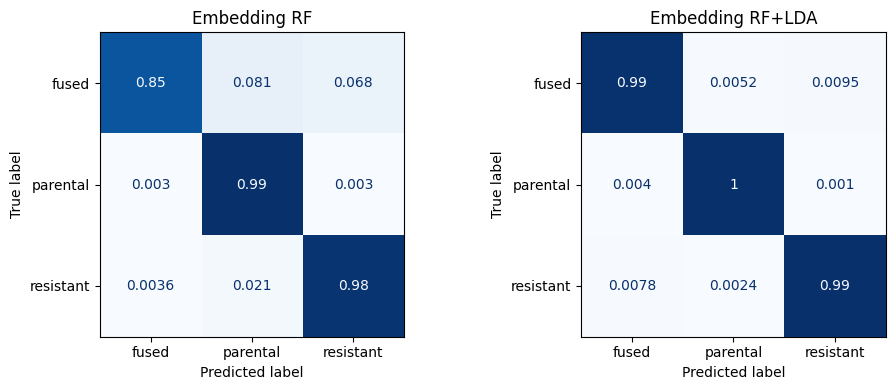

In [101]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
cm_rf_emb = confusion_matrix(y_emb_test_encoded, y_pred_rf_emb_enc, normalize='true')
ConfusionMatrixDisplay(confusion_matrix=cm_rf_emb, display_labels=le_emb.classes_).plot(
    ax=axes[0], cmap=plt.cm.Blues, colorbar=False
)
axes[0].set_title('Embedding RF')

cm_rf_lda_emb = confusion_matrix(y_emb_test_encoded, y_pred_rf_lda_emb_enc, normalize='true')
ConfusionMatrixDisplay(confusion_matrix=cm_rf_lda_emb, display_labels=le_emb.classes_).plot(
    ax=axes[1], cmap=plt.cm.Blues, colorbar=False
)
axes[1].set_title('Embedding RF+LDA')

plt.tight_layout()
plt.savefig('embedding_confusion_matrices.png')
plt.show()

## 8. Reproduce the Original HVG-Expression Classifiers

Re-run the original RF / RF+LDA classifiers from `Fusion_signature_Oct2025.ipynb` on `adata_combined_filtered`,
which is now built independently of the embedding branch using the exact original preprocessing
(`normalize_total(target_sum=1e6)` + plain `log1p`, no `exclude_highly_expressed`) — see Section 1.
Identical `random_state`/split/hyperparameter logic to the original notebook, so results should
match up to environment/version differences, and this stays true even as embedding-branch
preprocessing changes independently.

In [102]:
X_hvg = adata_combined_filtered.X
if hasattr(X_hvg, 'toarray'):
    X_hvg = X_hvg.toarray()
y_hvg = adata_combined_filtered.obs['sample'].values

X_hvg_train, X_hvg_test, y_hvg_train, y_hvg_test = train_test_split(
    X_hvg, y_hvg, test_size=0.2, random_state=42, stratify=y_hvg
)

selector_hvg = SelectKBest(score_func=f_classif, k=min(2000, X_hvg.shape[1]))

clf_rf_hvg = Pipeline([
    ('scaler', StandardScaler()),
    ('select', selector_hvg),
    ('clf', RandomForestClassifier(n_estimators=100, random_state=42)),
])
clf_rf_hvg.fit(X_hvg_train, y_hvg_train)
scores_rf_hvg = cross_val_score(clf_rf_hvg, X_hvg_train, y_hvg_train, cv=cv)
print('HVG RF - Training Accuracy: %.3f ± %.3f' % (scores_rf_hvg.mean(), scores_rf_hvg.std()))

lda_hvg = LinearDiscriminantAnalysis()
clf_rf_lda_hvg = Pipeline([
    ('scaler', StandardScaler()),
    ('select', selector_hvg),
    ('lda', lda_hvg),
    ('clf', RandomForestClassifier(n_estimators=100, random_state=42)),
])
clf_rf_lda_hvg.fit(X_hvg_train, y_hvg_train)
scores_rf_lda_hvg = cross_val_score(clf_rf_lda_hvg, X_hvg_train, y_hvg_train, cv=cv)
print('HVG RF+LDA - Training Accuracy: %.3f ± %.3f' % (scores_rf_lda_hvg.mean(), scores_rf_lda_hvg.std()))

y_pred_rf_hvg = clf_rf_hvg.predict(X_hvg_test)
y_pred_rf_lda_hvg = clf_rf_lda_hvg.predict(X_hvg_test)

print('HVG RF Test Accuracy:', accuracy_score(y_hvg_test, y_pred_rf_hvg))
print('HVG RF+LDA Test Accuracy:', accuracy_score(y_hvg_test, y_pred_rf_lda_hvg))

HVG RF - Training Accuracy: 0.917 ± 0.006
HVG RF+LDA - Training Accuracy: 0.951 ± 0.014
HVG RF Test Accuracy: 0.9148936170212766
HVG RF+LDA Test Accuracy: 0.9458789506300351


## 8b. Reproduce the Original HVG-Expression Classifiers but using updated pre-processing pipeline

Re-run the original RF / RF+LDA classifiers from `Fusion_signature_Oct2025.ipynb` on `adata_embed_input`
(the embedding branch's full 1548-gene panel: `exclude_highly_expressed=True, target_sum=1e8` +
`asinh`, no HVG subsetting/regression/scaling — see Section 1). Uses distinct `_embprep`-suffixed
variable names throughout so this can't overwrite Section 8's `scores_rf_hvg`/`y_pred_rf_hvg`/etc.
— it originally reused those exact names, which would silently corrupt Section 8's results (and
therefore the "HVG RF"/"HVG RF+LDA" bars in Section 9) on any top-to-bottom re-run.

In [103]:
X_embprep = adata_embed_input.X
if hasattr(X_embprep, 'toarray'):
    X_embprep = X_embprep.toarray()
y_embprep = adata_embed_input.obs['sample'].values

X_embprep_train, X_embprep_test, y_embprep_train, y_embprep_test = train_test_split(
    X_embprep, y_embprep, test_size=0.2, random_state=42, stratify=y_embprep
)

selector_embprep = SelectKBest(score_func=f_classif, k=min(2000, X_embprep.shape[1]))

clf_rf_embprep = Pipeline([
    ('scaler', StandardScaler()),
    ('select', selector_embprep),
    ('clf', RandomForestClassifier(n_estimators=100, random_state=42)),
])
clf_rf_embprep.fit(X_embprep_train, y_embprep_train)
scores_rf_embprep = cross_val_score(clf_rf_embprep, X_embprep_train, y_embprep_train, cv=cv)
print('HVG (embed-preproc) RF - Training Accuracy: %.3f ± %.3f' % (scores_rf_embprep.mean(), scores_rf_embprep.std()))

lda_embprep = LinearDiscriminantAnalysis()
clf_rf_lda_embprep = Pipeline([
    ('scaler', StandardScaler()),
    ('select', selector_embprep),
    ('lda', lda_embprep),
    ('clf', RandomForestClassifier(n_estimators=100, random_state=42)),
])
clf_rf_lda_embprep.fit(X_embprep_train, y_embprep_train)
scores_rf_lda_embprep = cross_val_score(clf_rf_lda_embprep, X_embprep_train, y_embprep_train, cv=cv)
print('HVG (embed-preproc) RF+LDA - Training Accuracy: %.3f ± %.3f' % (scores_rf_lda_embprep.mean(), scores_rf_lda_embprep.std()))

y_pred_rf_embprep = clf_rf_embprep.predict(X_embprep_test)
y_pred_rf_lda_embprep = clf_rf_lda_embprep.predict(X_embprep_test)

print('HVG (embed-preproc) RF Test Accuracy:', accuracy_score(y_embprep_test, y_pred_rf_embprep))
print('HVG (embed-preproc) RF+LDA Test Accuracy:', accuracy_score(y_embprep_test, y_pred_rf_lda_embprep))

HVG (embed-preproc) RF - Training Accuracy: 0.978 ± 0.004
HVG (embed-preproc) RF+LDA - Training Accuracy: 0.995 ± 0.001
HVG (embed-preproc) RF Test Accuracy: 0.978103697583144
HVG (embed-preproc) RF+LDA Test Accuracy: 0.9960751910762239


## 9. Compare Embedding-Based vs. HVG-Expression-Based Classifiers

Side-by-side CV accuracy (boxplot) and test-set metrics for three groups: RF and RF+LDA trained on
the `sc_embedd` embedding (Section 7), on the original HVG-expression pipeline (Section 8), and on
the embedding branch's full-panel preprocessing without HVG subsetting (Section 8b).

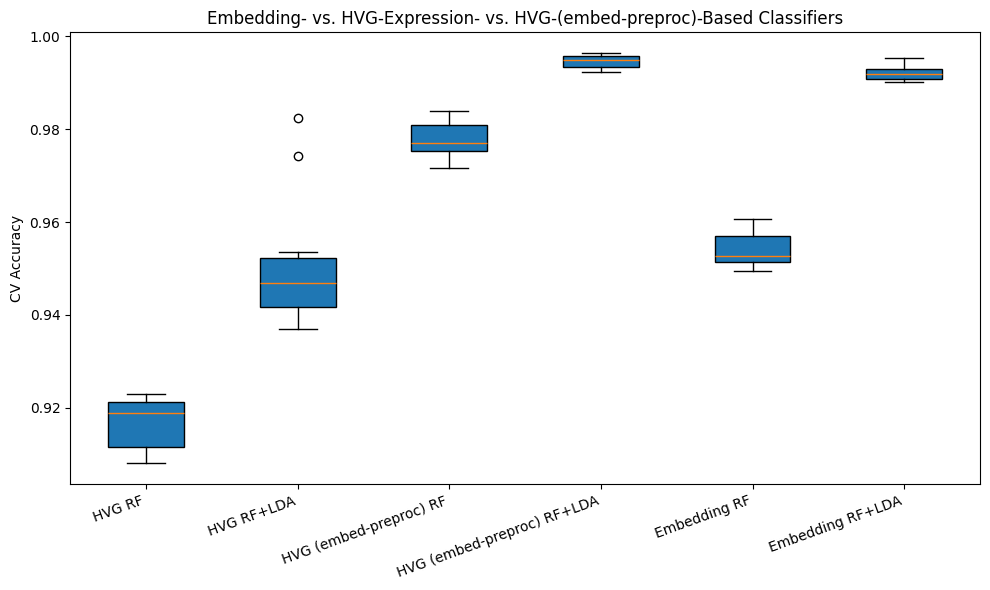

In [104]:
dict_res = {
    'HVG RF': scores_rf_hvg,
    'HVG RF+LDA': scores_rf_lda_hvg,
    'HVG (embed-preproc) RF': scores_rf_embprep,
    'HVG (embed-preproc) RF+LDA': scores_rf_lda_embprep,
    'Embedding RF': scores_rf_emb,
    'Embedding RF+LDA': scores_rf_lda_emb,
}
categories = list(dict_res.keys())
values = list(dict_res.values())

plt.figure(figsize=(10, 6))
plt.boxplot(values, patch_artist=True, tick_labels=categories)
plt.ylabel('CV Accuracy')
plt.title('Embedding- vs. HVG-Expression- vs. HVG-(embed-preproc)-Based Classifiers')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('embedding_vs_hvg_cv_accuracy.png')
plt.show()

In [105]:
comparison_df = pd.DataFrame({
    'model': categories,
    'cv_accuracy_mean': [v.mean() for v in values],
    'cv_accuracy_std': [v.std() for v in values],
    'test_accuracy': [
        accuracy_score(y_hvg_test, y_pred_rf_hvg),
        accuracy_score(y_hvg_test, y_pred_rf_lda_hvg),
        accuracy_score(y_embprep_test, y_pred_rf_embprep),
        accuracy_score(y_embprep_test, y_pred_rf_lda_embprep),
        accuracy_score(y_emb_test, y_pred_rf_emb),
        accuracy_score(y_emb_test, y_pred_rf_lda_emb),
    ],
})
comparison_df

,model,cv_accuracy_mean,cv_accuracy_std,test_accuracy
0,HVG RF,0.916649,0.005532,0.914894
1,HVG RF+LDA,0.951353,0.014338,0.945879
2,HVG (embed-preproc) RF,0.977587,0.003887,0.978104
3,HVG (embed-preproc) RF+LDA,0.994629,0.001351,0.996075
4,Embedding RF,0.954091,0.003597,0.953315
5,Embedding RF+LDA,0.992047,0.001535,0.990911


## 10. ROC Curves — Embedding-Based Classifiers

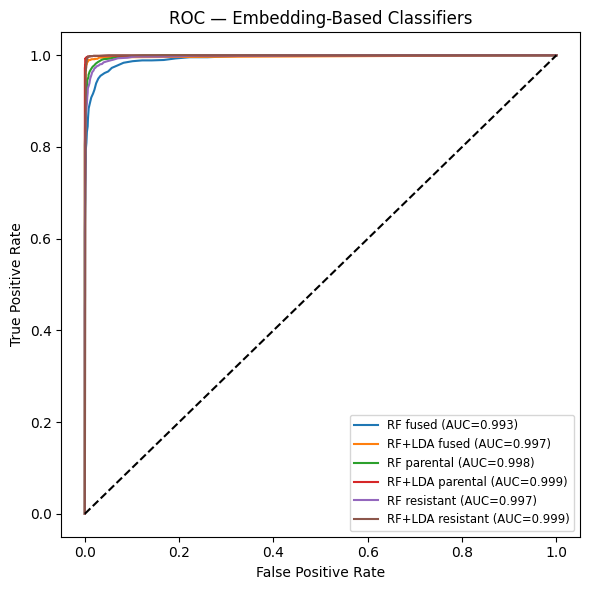

In [106]:
y_score_rf_emb = clf_rf_emb.predict_proba(X_emb_test)
y_score_rf_lda_emb = clf_rf_lda_emb.predict_proba(X_emb_test)

classes_emb = np.unique(y_emb_test)
y_bin_emb = label_binarize(y_emb_test, classes=classes_emb)

plt.figure(figsize=(6, 6))
for i, class_name in enumerate(classes_emb):
    fpr_rf, tpr_rf, _ = roc_curve(y_bin_emb[:, i], y_score_rf_emb[:, i])
    auc_rf = roc_auc_score(y_bin_emb[:, i], y_score_rf_emb[:, i])

    fpr_lda, tpr_lda, _ = roc_curve(y_bin_emb[:, i], y_score_rf_lda_emb[:, i])
    auc_lda = roc_auc_score(y_bin_emb[:, i], y_score_rf_lda_emb[:, i])

    plt.plot(fpr_rf, tpr_rf, label=f'RF {class_name} (AUC={auc_rf:.3f})')
    plt.plot(fpr_lda, tpr_lda, label=f'RF+LDA {class_name} (AUC={auc_lda:.3f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC — Embedding-Based Classifiers')
plt.legend(fontsize='small')
plt.tight_layout()
plt.savefig('ROC_embedding.png')
plt.show()

## 11. Gene-Level Attribution for the Embedding Classifiers (Section 7)

**Advisor feedback on the original version of this section**: the first pass here multiplied
gene-to-embedding-dimension correlation by RF `feature_importances_` / LDA `scalings_` magnitude.
Those are two different domains -- correlation is a unitless, population-level association
statistic; RF importance is impurity decrease, not a marginal effect on the output. Multiplying
them doesn't answer "how much does a unit change in this gene's expression change the model's
output score," and it collapses everything to one number per gene across the whole population,
hiding the fact that different fused cells might reach the same call through different genes
(multiple genotypes, one phenotype).

The quick-screen cell below keeps the old correlation-based heuristic only as a cheap way to
shortlist candidate genes if the full permutation sweep (Section 11a) is too slow to run on all
1548 genes -- it no longer produces the gene ranking used downstream.

**Section 11a is the canonical method now**: a permutation-based sensitivity computed per cell, in
real output-probability units, chained through the actual fitted model and classifier rather than
approximated by a proxy statistic:

1. For each gene, permute (shuffle across cells) just that gene's values, holding every other gene
   and every cell's identity fixed, and re-run the real `sc_embedd` encoder to get each cell's
   perturbed embedding.
2. Feed the perturbed embedding through the actual fitted classifier (`clf_rf_emb` /
   `clf_rf_lda_emb`) and record the change in `predict_proba` for the class of interest
   (`SCORE_CLASS`) -- a genuine "how much did the output score move," per cell, in probability
   units, not an approximation.
3. Aggregate `mean(|Δscore|)` per gene, primarily across cells that truly belong to `SCORE_CLASS`
   (most relevant for a signature specific to that phenotype), with the all-cells aggregate kept
   for context.

Section 11b then looks at the per-cell Δscore matrix directly (not just its aggregate) across
`SCORE_CLASS` cells, to check for exactly the heterogeneity the correlation-based version couldn't
see.

In [ ]:
# --- Optional / fast quick-screen (approximate) ---
# This is the population-level correlation x RF-importance heuristic from the first version of this
# analysis. Kept only as a cheap way to shortlist candidate genes (e.g. for
# GENE_SUBSET_FOR_SENSITIVITY below) -- it is NOT used to build the canonical gene ranking anymore.
# See Section 11a: correlation (unitless, population-level) and RF feature_importances_
# (impurity-decrease, not a marginal effect) are two different domains -- multiplying them isn't a
# real "how much does the output change" measure, and it can't see per-cell heterogeneity.
def zscore_cols(X):
    mu = X.mean(axis=0, keepdims=True)
    sd = X.std(axis=0, keepdims=True)
    sd[sd == 0] = 1.0
    return (X - mu) / sd

expr_z = zscore_cols(expr)          # (n_cells, 1548)
emb_z = zscore_cols(emb_res)        # (n_cells, 128)
quick_gene_dim_corr = (expr_z.T @ emb_z) / expr_z.shape[0]   # (1548, 128)

quick_rf_dim_importance = clf_rf_emb['clf'].feature_importances_       # (128,)
quick_lda_dim_importance = np.abs(clf_rf_lda_emb['lda'].scalings_).sum(axis=1)  # (128,)

def quick_project_to_genes(dim_importance, corr):
    return np.abs(corr) @ dim_importance

quick_screen_df = pd.DataFrame({
    'feature': adata_embed_input.var_names,
    'rf_score': quick_project_to_genes(quick_rf_dim_importance, quick_gene_dim_corr),
    'lda_score': quick_project_to_genes(quick_lda_dim_importance, quick_gene_dim_corr),
})
for col in ('rf_score', 'lda_score'):
    rng_span = quick_screen_df[col].max() - quick_screen_df[col].min()
    quick_screen_df[col + '_norm'] = (
        (quick_screen_df[col] - quick_screen_df[col].min()) / (rng_span if rng_span > 0 else 1.0)
    )
quick_screen_df['quick_combined_score'] = quick_screen_df['rf_score_norm'] + quick_screen_df['lda_score_norm']
quick_screen_ranking = quick_screen_df.sort_values('quick_combined_score', ascending=False)['feature'].tolist()
quick_screen_df.sort_values('quick_combined_score', ascending=False).head(30)

## 11a. Permutation-Based Sensitivity (Output-Score Domain, Per-Cell)

This is the canonical method -- its output (`features_df_emb` / `top_genes_emb`) is what Sections
12 and 13 use. Config knobs below trade off runtime vs. coverage; cost is roughly
`(genes tested) x (repeats) x (cells / batch size)` forward passes through the encoder.

In [ ]:
SCORE_CLASS = 'fused'  # which class's predict_proba we track as "the output score"
N_PERMUTATION_REPEATS = 1  # >1 averages over repeated permutations to reduce noise, at proportional cost
MAX_CELLS_FOR_SENSITIVITY = 1500  # cells used (stratified across classes); None = use all cells (expensive)
GENE_SUBSET_FOR_SENSITIVITY = None  # e.g. quick_screen_ranking[:200] to restrict to a fast shortlist; None = all 1548 genes
SENSITIVITY_BATCH_SIZE = 256  # TF-level batch size within each vectorized chunk (see GENE_CHUNK_SIZE below)
GENE_CHUNK_SIZE = 25  # how many (gene, repeat) perturbation units to stack into one forward pass --
                       # this is the vectorization knob: instead of one full model pass per gene
                       # (1548 separate passes, each mostly Python/TF dispatch overhead since only one
                       # column differs), GENE_CHUNK_SIZE perturbed copies of the cell subset are
                       # tiled together and run as one larger batch. Higher = fewer, bigger forward
                       # passes = faster, at the cost of ~GENE_CHUNK_SIZE x MAX_CELLS_FOR_SENSITIVITY x
                       # 1548 x 4 bytes of host memory for the staging array (25 x 1500 x 1548 x 4
                       # bytes ≈ 232MB at the defaults) -- raise it if memory allows, lower it if not.
SENSITIVITY_RANDOM_SEED = 42

print(f'SCORE_CLASS={SCORE_CLASS!r}, N_PERMUTATION_REPEATS={N_PERMUTATION_REPEATS}, '
      f'MAX_CELLS_FOR_SENSITIVITY={MAX_CELLS_FOR_SENSITIVITY}, GENE_CHUNK_SIZE={GENE_CHUNK_SIZE}, '
      f'genes to test: {"all 1548" if GENE_SUBSET_FOR_SENSITIVITY is None else len(GENE_SUBSET_FOR_SENSITIVITY)}')
print('If this is too slow, cut MAX_CELLS_FOR_SENSITIVITY first, or restrict '
      'GENE_SUBSET_FOR_SENSITIVITY to a shortlist (e.g. from the quick screen above) to validate '
      'the approach before committing to the full 1548-gene sweep. If it is too slow but memory '
      'allows, raise GENE_CHUNK_SIZE instead of (or before) cutting coverage.')

In [ ]:
rng_sens = np.random.default_rng(SENSITIVITY_RANDOM_SEED)
sample_labels_all = adata_embed_input.obs['sample'].values
class_idx_map_emb = {c: np.where(sample_labels_all == c)[0] for c in np.unique(sample_labels_all)}

if MAX_CELLS_FOR_SENSITIVITY is not None:
    per_class_cap = MAX_CELLS_FOR_SENSITIVITY // len(class_idx_map_emb)
    sens_cell_idx = np.concatenate([
        rng_sens.choice(idx, size=min(per_class_cap, len(idx)), replace=False)
        for idx in class_idx_map_emb.values()
    ])
else:
    sens_cell_idx = np.arange(adata_embed_input.n_obs)

sens_labels = sample_labels_all[sens_cell_idx]
within_class_mask = sens_labels == SCORE_CLASS
print(f'Using {len(sens_cell_idx)} cells for the sensitivity analysis '
      f'(class counts: {pd.Series(sens_labels).value_counts().to_dict()}); '
      f'{within_class_mask.sum()} belong to SCORE_CLASS={SCORE_CLASS!r}.')

expr_sens = expr[sens_cell_idx]
x_batch_sens = x_batch[sens_cell_idx]
emb_sens = emb_res[sens_cell_idx]   # already-computed, unperturbed embedding for this subset

class_list_emb = list(clf_rf_emb.classes_)
assert class_list_emb == list(clf_rf_lda_emb.classes_), 'clf_rf_emb / clf_rf_lda_emb disagree on class order'
score_class_idx = class_list_emb.index(SCORE_CLASS)

score_rf_orig = clf_rf_emb.predict_proba(emb_sens)[:, score_class_idx]
score_rf_lda_orig = clf_rf_lda_emb.predict_proba(emb_sens)[:, score_class_idx]

gene_col_index = {g: i for i, g in enumerate(adata_embed_input.var_names)}
genes_to_test = GENE_SUBSET_FOR_SENSITIVITY if GENE_SUBSET_FOR_SENSITIVITY is not None else list(adata_embed_input.var_names)
gene_test_positions = [gene_col_index[g] for g in genes_to_test]
print(f'Testing {len(genes_to_test)} genes.')

In [ ]:
# Vectorized: instead of one full model forward pass per gene (1548 separate passes, each mostly
# Python/TF dispatch overhead since only one column differs from the unperturbed input), stack
# GENE_CHUNK_SIZE perturbed copies of the cell subset together and run them as one larger batch.
# The math is identical to the per-gene loop -- this only changes how the work is dispatched.
n_sens_cells = expr_sens.shape[0]
n_genes_tested = len(genes_to_test)

delta_score_rf = np.zeros((n_sens_cells, n_genes_tested), dtype=np.float32)
delta_score_rf_lda = np.zeros((n_sens_cells, n_genes_tested), dtype=np.float32)

# One "unit" = one (gene, repeat) perturbation to run through the model. Chunking over units (not
# just genes) keeps N_PERMUTATION_REPEATS > 1 vectorized too.
units = [(gi, col_pos) for gi, col_pos in enumerate(gene_test_positions) for _ in range(N_PERMUTATION_REPEATS)]
n_units = len(units)
n_chunks = (n_units + GENE_CHUNK_SIZE - 1) // GENE_CHUNK_SIZE

for chunk_i, chunk_start in enumerate(range(0, n_units, GENE_CHUNK_SIZE)):
    chunk = units[chunk_start:chunk_start + GENE_CHUNK_SIZE]
    C = len(chunk)

    expr_block = np.tile(expr_sens, (C, 1))        # (C * n_sens_cells, n_genes_total)
    x_batch_block = np.tile(x_batch_sens, (C, 1))   # (C * n_sens_cells, BATCH_WIDTH)

    for j, (gi, col_pos) in enumerate(chunk):
        perm = rng_sens.permutation(n_sens_cells)
        block_rows = slice(j * n_sens_cells, (j + 1) * n_sens_cells)
        expr_block[block_rows, col_pos] = expr_sens[perm, col_pos]  # break this gene's cell identity only

    ds_block = tf.data.Dataset.from_tensor_slices((expr_block, x_batch_block)).batch(SENSITIVITY_BATCH_SIZE)
    emb_chunks = []
    for local_batch in ds_block:
        out = call_fn(local_batch[0], local_batch[1])
        if isinstance(out, dict):
            out = list(out.values())
        emb_chunks.append(out[0].numpy())
    emb_block = np.vstack(emb_chunks).reshape(C, n_sens_cells, -1)  # (C, n_cells, latent_dim)

    emb_flat = emb_block.reshape(C * n_sens_cells, -1)
    score_rf_block = clf_rf_emb.predict_proba(emb_flat)[:, score_class_idx].reshape(C, n_sens_cells)
    score_rf_lda_block = clf_rf_lda_emb.predict_proba(emb_flat)[:, score_class_idx].reshape(C, n_sens_cells)

    for j, (gi, col_pos) in enumerate(chunk):
        delta_score_rf[:, gi] += (score_rf_block[j] - score_rf_orig) / N_PERMUTATION_REPEATS
        delta_score_rf_lda[:, gi] += (score_rf_lda_block[j] - score_rf_lda_orig) / N_PERMUTATION_REPEATS

    if (chunk_i + 1) % 10 == 0 or (chunk_i + 1) == n_chunks:
        print(f'\rChunk {chunk_i + 1}/{n_chunks} done ({chunk_start + C}/{n_units} units)', end='')

print(f'\nDone. delta_score_rf shape: {delta_score_rf.shape}')

In [ ]:
rf_delta_within = np.abs(delta_score_rf[within_class_mask]).mean(axis=0)
rf_delta_all = np.abs(delta_score_rf).mean(axis=0)
rf_lda_delta_within = np.abs(delta_score_rf_lda[within_class_mask]).mean(axis=0)
rf_lda_delta_all = np.abs(delta_score_rf_lda).mean(axis=0)

features_df_emb = pd.DataFrame({
    'feature': genes_to_test,
    'rf_delta_within_class': rf_delta_within,      # mean |Δ predict_proba| among SCORE_CLASS cells
    'rf_lda_delta_within_class': rf_lda_delta_within,
    'rf_delta_all_cells': rf_delta_all,             # same, averaged over all sensitivity cells (context)
    'rf_lda_delta_all_cells': rf_lda_delta_all,
})

# Both columns are now in the same domain (change in predict_proba) -- normalize only to give the
# two classifiers equal weight in the combined ranking, not to fix a domain mismatch.
for col in ('rf_delta_within_class', 'rf_lda_delta_within_class'):
    rng_span = features_df_emb[col].max() - features_df_emb[col].min()
    features_df_emb[col + '_norm'] = (
        (features_df_emb[col] - features_df_emb[col].min()) / (rng_span if rng_span > 0 else 1.0)
    )
features_df_emb['combined_score'] = (
    features_df_emb['rf_delta_within_class_norm'] + features_df_emb['rf_lda_delta_within_class_norm']
)

top_genes_emb = features_df_emb.sort_values('combined_score', ascending=False).reset_index(drop=True)
top_genes_emb.head(30)

## 11b. Per-Cell Sensitivity Heterogeneity Within the Fused Class

Different fused cells might rely on different genes to reach the same call -- multiple genotypes
converging on one phenotype. This clusters `SCORE_CLASS` cells by their per-gene Δscore profile
(RF classifier, top genes from the ranking above) to check for that directly, instead of assuming
one signature explains every fused cell equally.

In [ ]:
N_HEATMAP_GENES = 30
heatmap_genes = top_genes_emb['feature'].head(N_HEATMAP_GENES).tolist()
heatmap_gene_positions = [genes_to_test.index(g) for g in heatmap_genes]

within_class_delta = delta_score_rf[within_class_mask][:, heatmap_gene_positions]
heatmap_df = pd.DataFrame(within_class_delta, columns=heatmap_genes)

g_cluster = sns.clustermap(heatmap_df, cmap='vlag', center=0, figsize=(10, 10),
                            xticklabels=True, yticklabels=False)
g_cluster.fig.suptitle(f'Per-Cell Δ{SCORE_CLASS}-probability Across {SCORE_CLASS} Cells (RF)', y=1.02)
g_cluster.savefig('fused_cell_sensitivity_heterogeneity_heatmap.png')
plt.show()

In [ ]:
plt.figure(figsize=(10, 8))
top30 = top_genes_emb.head(30)
plt.barh(top30['feature'], top30['combined_score'])
plt.xlabel('Combined (normalized) Sensitivity Score')
plt.title('Top 30 Genes by Permutation Sensitivity (Δ predict_proba) -- Embedding RF/RF+LDA')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('top30_genes_embedding_classifiers.png')
plt.show()

## 12. Pathway Enrichment (GSEA) on the Permutation-Sensitivity Gene Ranking

Same Enrichr call as `Fusion_signature_Oct2025.ipynb`, run on the full permutation-sensitivity gene
ranking (Section 11a) and on the top 30, against MSigDB Hallmark and KEGG. Even the permutation
ranking is a per-run estimate (fixed permutation draws, a specific `SCORE_CLASS`/cell subsample) --
treat enrichment results as hypothesis-generating, and cross-check against Section 13's minimal
panel (validated by actually retraining on it) before reading too much into any single pathway
hit.

In [110]:
all_genes_emb = top_genes_emb['feature'].str.strip().tolist()
enr_emb_all = gp.enrichr(
    gene_list=all_genes_emb,
    gene_sets=['MSigDB_Hallmark_2020', 'KEGG_2021_Human'],
    organism='human',
    outdir='enrichr_results_embedding_all',
    cutoff=1.0,
)
enr_emb_all.results.head()

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,MSigDB_Hallmark_2020,TNF-alpha Signaling via NF-kB,80/200,3.418924e-37,8.547310e-36,0,0,8.325159,699.032981,CDKN1A;TNFAIP8;BTG1;SERPINE1;TNC;TNFAIP2;TNFAI...
1,MSigDB_Hallmark_2020,Epithelial Mesenchymal Transition,80/200,3.418924e-37,8.547310e-36,0,0,8.325159,699.032981,CXCL8;MCM7;WIPF1;ITGB3;SERPINE1;COL12A1;TNC;TN...
2,MSigDB_Hallmark_2020,G2-M Checkpoint,68/200,8.372786e-27,1.395464e-25,0,0,6.376740,382.890170,TOP2A;HMGB3;KIF11;MKI67;BRCA2;SMC4;SMC2;LMNB1;...
3,MSigDB_Hallmark_2020,E2F Targets,61/200,2.146766e-21,2.683457e-20,0,0,5.404600,257.206671,TOP2A;CDKN1A;TFRC;MCM7;HMGB2;BUB1B;HMGB3;BRCA1...
4,MSigDB_Hallmark_2020,Mitotic Spindle,54/199,1.338495e-16,1.147035e-15,0,0,4.563440,166.792890,TOP2A;DOCK4;TRIO;KIF11;BRCA2;SMC4;LMNB1;CNTRL;...


               Gene_set             Term Overlap       P-value  \
0  MSigDB_Hallmark_2020  G2-M Checkpoint  16/200  6.983787e-25   
1  MSigDB_Hallmark_2020      E2F Targets  13/200  6.953466e-19   
2  MSigDB_Hallmark_2020  Mitotic Spindle  11/199  3.317326e-15   
3  MSigDB_Hallmark_2020       Glycolysis   4/200  2.169064e-04   
4  MSigDB_Hallmark_2020  Spermatogenesis   3/135  1.068584e-03   

   Adjusted P-value  Old P-value  Old Adjusted P-value  Odds Ratio  \
0      1.536433e-23            0                     0  122.894410   
1      7.648812e-18            0                     0   80.899339   
2      2.432706e-14            0                     0   60.918813   
3      1.192985e-03            0                     0   15.521193   
4      4.701770e-03            0                     0   16.698653   

   Combined Score                                              Genes  
0     6835.514405  TOP2A;ODC1;PLK1;HMMR;MKI67;NDC80;CKS1B;AURKA;C...  
1     3382.391397  TOP2A;PLK1;HMGB2;HMMR

/tmp/job.3718850.pioneer/ipykernel_2866590/3236873315.py:19: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


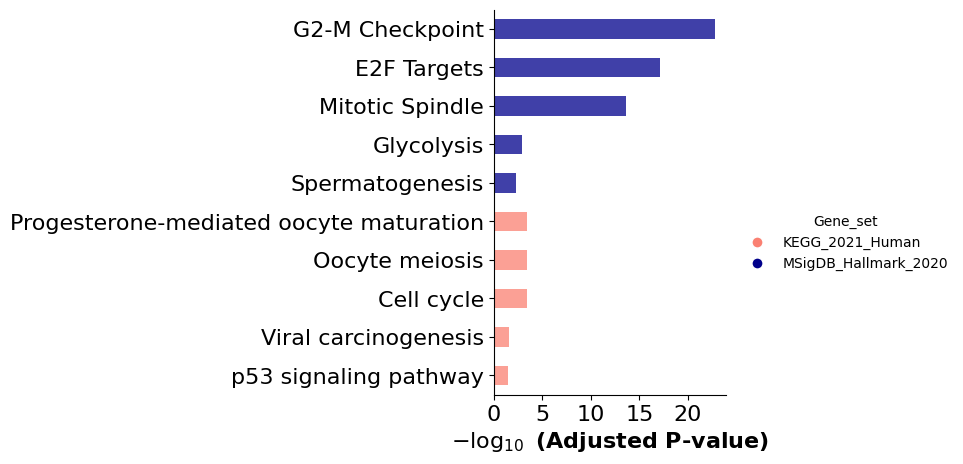

In [112]:
top30_genes_emb = top_genes_emb['feature'].head(30).str.strip().tolist()
enr_emb_top30 = gp.enrichr(
    gene_list=top30_genes_emb,
    gene_sets=['MSigDB_Hallmark_2020', 'KEGG_2021_Human'],
    organism='human',
    outdir='enrichr_results_embedding_top30',
    cutoff=1.0,
)
print(enr_emb_top30.results.head())

ax = barplot(enr_emb_top30.results,
             column='Adjusted P-value',
             group='Gene_set',
             size=10,
             top_term=5,
             figsize=(3, 5),
             color={'KEGG_2021_Human': 'salmon', 'MSigDB_Hallmark_2020': 'darkblue'},
             cutoff=2.0)
plt.tight_layout()
plt.savefig('enrichr_embedding_top30_barplot.png')
plt.show()

## 13. Minimum Feature Count for a Compact Fusion Signature

Retrains simple RF and RF+LDA classifiers directly on just the top-K genes (by the Section 11a
permutation-sensitivity ranking, sliced from `adata_embed_input.X`) for a sweep of K, and evaluates
10-fold CV accuracy *and* log-loss at each K -- both curves (RF, RF+LDA) are kept for comparison,
but the minimal-K decision and the final signature classifier below use **RF only**, no LDA, to
avoid adding another fit on top of an already-small gene panel (more overfitting risk than benefit
at this scale). This validates the permutation-sensitivity ranking on its own terms -- can these
genes, used directly (no neural embedding involved), actually separate fused/parental/resistant? --
rather than trusting the Section 11a estimate (fixed cell subsample / permutation draws) alone.

**How K is chosen**: the canonical `MIN_K` is now the K that minimizes a pseudo-BIC, not an
arbitrary accuracy-tolerance cutoff. RF has no real likelihood to plug into a textbook BIC, so this
substitutes 10-fold CV log-loss for `-ln(L)` and treats K (genes used) as the complexity/parameter
count being penalized -- the right substitution for *this* question, since what we actually want to
penalize is signature length, not the RF's internal tree complexity. `BIC = 2*n*logloss + K*ln(n)`;
AIC uses `2*K` instead of `K*ln(n)` and penalizes size less harshly (`ln(n) > 2` whenever `n > 7`,
always true here), so it tends to pick a larger panel -- both are computed and plotted, and the old
tolerance-based K is kept alongside as a sanity check, not deleted.

In [ ]:
K_SWEEP = [5, 10, 20, 30, 50, 75, 100, 150, 200, 300, 500, 750, 1000, 1548]
TOLERANCE = 0.02  # accept any K within 2 percentage points of the sweep's best CV accuracy

gene_ranking_emb = top_genes_emb['feature'].tolist()
gene_index_emb = {g: i for i, g in enumerate(adata_embed_input.var_names)}
X_full_embprep = adata_embed_input.X
y_full_embprep = adata_embed_input.obs['sample'].values
n_samples_sweep = X_full_embprep.shape[0]

sweep_rows = []
for k in K_SWEEP:
    cols = [gene_index_emb[g] for g in gene_ranking_emb[:k]]
    X_k = X_full_embprep[:, cols]

    pipe_rf_k = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ])
    cv_rf_k = cross_validate(pipe_rf_k, X_k, y_full_embprep, cv=cv, scoring=['accuracy', 'neg_log_loss'])

    pipe_rf_lda_k = Pipeline([
        ('scaler', StandardScaler()),
        ('lda', LinearDiscriminantAnalysis()),
        ('clf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ])
    cv_rf_lda_k = cross_validate(pipe_rf_lda_k, X_k, y_full_embprep, cv=cv, scoring=['accuracy', 'neg_log_loss'])

    rf_mean, rf_std = cv_rf_k['test_accuracy'].mean(), cv_rf_k['test_accuracy'].std()
    rf_lda_mean, rf_lda_std = cv_rf_lda_k['test_accuracy'].mean(), cv_rf_lda_k['test_accuracy'].std()
    rf_logloss = -cv_rf_k['test_neg_log_loss'].mean()
    rf_lda_logloss = -cv_rf_lda_k['test_neg_log_loss'].mean()

    # Pseudo information criteria: RF has no real likelihood, so this substitutes CV log-loss for
    # -ln(L) and treats K (genes used) as the complexity/parameter count -- the natural choice here
    # since we specifically want to penalize *signature length*, not the RF's internal complexity.
    rf_bic = 2 * n_samples_sweep * rf_logloss + k * np.log(n_samples_sweep)
    rf_aic = 2 * n_samples_sweep * rf_logloss + 2 * k
    rf_lda_bic = 2 * n_samples_sweep * rf_lda_logloss + k * np.log(n_samples_sweep)
    rf_lda_aic = 2 * n_samples_sweep * rf_lda_logloss + 2 * k

    sweep_rows.append({
        'k': k,
        'rf_mean': rf_mean, 'rf_std': rf_std,
        'rf_lda_mean': rf_lda_mean, 'rf_lda_std': rf_lda_std,
        'rf_logloss': rf_logloss, 'rf_lda_logloss': rf_lda_logloss,
        'rf_bic': rf_bic, 'rf_aic': rf_aic,
        'rf_lda_bic': rf_lda_bic, 'rf_lda_aic': rf_lda_aic,
    })
    print(f'k={k:4d}  RF={rf_mean:.3f}±{rf_std:.3f} (logloss={rf_logloss:.3f}, BIC={rf_bic:.1f})  '
          f'RF+LDA={rf_lda_mean:.3f}±{rf_lda_std:.3f} (logloss={rf_lda_logloss:.3f}, BIC={rf_lda_bic:.1f})')

sweep_df = pd.DataFrame(sweep_rows)

# Tolerance-based pick (old heuristic, kept for comparison) -- RF-only, since the final signature
# classifier below is RF-only.
best_rf = sweep_df['rf_mean'].max()
tol_row = sweep_df[sweep_df['rf_mean'] >= best_rf - TOLERANCE].iloc[0]
MIN_K_TOLERANCE = int(tol_row['k'])

# BIC-based pick (primary/canonical): the K that minimizes RF's pseudo-BIC across the sweep -- a
# principled fit-vs-length trade-off with no arbitrary tolerance to hand-pick. AIC (2*K penalty vs
# BIC's K*ln(n)) tends to prefer a larger panel -- included for comparison, not used as the default.
bic_row = sweep_df.loc[sweep_df['rf_bic'].idxmin()]
aic_row = sweep_df.loc[sweep_df['rf_aic'].idxmin()]
MIN_K_BIC = int(bic_row['k'])
MIN_K_AIC = int(aic_row['k'])

MIN_K = MIN_K_BIC  # canonical choice used by the final signature classifier below

print(f'\nBest RF CV accuracy across the sweep: {best_rf:.3f}')
print(f'Tolerance-based K (within {TOLERANCE:.0%} of best accuracy): {MIN_K_TOLERANCE}')
print(f'BIC-minimizing K: {MIN_K_BIC} (BIC={bic_row["rf_bic"]:.1f}, accuracy={bic_row["rf_mean"]:.3f})')
print(f'AIC-minimizing K: {MIN_K_AIC} (AIC={aic_row["rf_aic"]:.1f}, accuracy={aic_row["rf_mean"]:.3f})')
print(f'Using MIN_K = {MIN_K} (BIC) for the final signature classifier below.')

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax = axes[0]
ax.errorbar(sweep_df['k'], sweep_df['rf_mean'], yerr=sweep_df['rf_std'], marker='o', label='RF')
ax.errorbar(sweep_df['k'], sweep_df['rf_lda_mean'], yerr=sweep_df['rf_lda_std'], marker='o', label='RF+LDA')
ax.axhline(best_rf - TOLERANCE, color='gray', linestyle='--', linewidth=1,
           label=f'RF best - {TOLERANCE:.0%}')
ax.axvline(MIN_K_TOLERANCE, color='gray', linestyle=':', linewidth=1, label=f'Tolerance K={MIN_K_TOLERANCE}')
ax.axvline(MIN_K_BIC, color='red', linestyle=':', linewidth=1.5, label=f'BIC K={MIN_K_BIC}')
ax.set_xscale('log')
ax.set_xlabel('Number of top genes (K)')
ax.set_ylabel('10-fold CV Accuracy')
ax.set_title('Accuracy vs. Gene Panel Size')
ax.legend(fontsize='small')

ax2 = axes[1]
ax2.plot(sweep_df['k'], sweep_df['rf_bic'], marker='o', label='RF BIC')
ax2.plot(sweep_df['k'], sweep_df['rf_aic'], marker='o', label='RF AIC')
ax2.axvline(MIN_K_BIC, color='red', linestyle=':', linewidth=1.5, label=f'BIC min K={MIN_K_BIC}')
ax2.axvline(MIN_K_AIC, color='darkorange', linestyle=':', linewidth=1.5, label=f'AIC min K={MIN_K_AIC}')
ax2.set_xscale('log')
ax2.set_xlabel('Number of top genes (K)')
ax2.set_ylabel('Pseudo information criterion (lower = better)')
ax2.set_title('BIC/AIC vs. Gene Panel Size (RF)')
ax2.legend(fontsize='small')

plt.tight_layout()
plt.savefig('min_feature_sweep.png')
plt.show()

In [ ]:
fusion_signature_genes = gene_ranking_emb[:MIN_K]
print(f'Candidate fusion signature ({MIN_K} genes, BIC-selected):')
print(fusion_signature_genes)

cols = [gene_index_emb[g] for g in fusion_signature_genes]
X_sig = X_full_embprep[:, cols]

X_sig_train, X_sig_test, y_sig_train, y_sig_test = train_test_split(
    X_sig, y_full_embprep, test_size=0.2, random_state=42, stratify=y_full_embprep
)

# RF only, not RF+LDA -- LDA adds another fit step on top of an already-small gene panel, which
# for a signature this compact is more likely to overfit than to help.
clf_rf_sig = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(n_estimators=100, random_state=42)),
])
clf_rf_sig.fit(X_sig_train, y_sig_train)
y_pred_sig = clf_rf_sig.predict(X_sig_test)
print('\nFusion-signature RF Test Accuracy:', accuracy_score(y_sig_test, y_pred_sig))
print(classification_report(y_sig_test, y_pred_sig))

joblib.dump(clf_rf_sig, 'fusion_signature_classifier.pkl')
pd.Series(fusion_signature_genes, name='gene').to_csv('fusion_signature_genes.csv', index=False)

# Companion export for the pseudo-bulk deconvolution notebook: signature-gene expression (in the
# same preprocessing space the classifier was trained on) for every cell, not just the test split,
# plus true sample labels -- avoids re-running the whole embedding pipeline just to get these
# columns in a separate notebook.
sig_adata = adata_embed_input[:, fusion_signature_genes].copy()
sig_adata.write_h5ad('fusion_signature_expression.h5ad')
print(f"Wrote fusion_signature_expression.h5ad: {sig_adata.shape[0]} cells x {sig_adata.shape[1]} genes")

In [ ]:
enr_signature = gp.enrichr(
    gene_list=[g.strip() for g in fusion_signature_genes],
    gene_sets=['MSigDB_Hallmark_2020', 'KEGG_2021_Human'],
    organism='human',
    outdir='enrichr_results_fusion_signature',
    cutoff=1.0,
)
print(enr_signature.results.head(10))

ax = barplot(enr_signature.results,
             column='Adjusted P-value',
             group='Gene_set',
             size=10,
             top_term=5,
             figsize=(3, 5),
             color={'KEGG_2021_Human': 'salmon', 'MSigDB_Hallmark_2020': 'darkblue'},
             cutoff=2.0)
plt.tight_layout()
plt.savefig('enrichr_fusion_signature_barplot.png')
plt.show()